<a href="https://colab.research.google.com/github/hspanja1/SPM-nonlinear-threshold-ssfm/blob/main/OTS_projekat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Ćelija 1: Uvoz biblioteka

# NumPy se koristi za numeričko rješavanje NLSE jednadžbe i rad s matricama signala
import numpy as np

# Matplotlib koristimo za vizualizaciju rezultata: spektra, talasnog oblika i nelinearnog praga
import matplotlib.pyplot as plt


In [ ]:
#Ćelija 2: Fizikalne konstante i bazni parametri

# Brzina svjetlosti u vakuumu [m/s]
c = 3e8

# Središnja talasna dužina signala (standardni C-opseg) [m]
lambda0 = 1550e-9

# Izračun optičke frekvencije (nu) na osnovu zadane talasne dužine [Hz]
nu = c / lambda0

# Planckova konstanta – bitna za proračun ASE šuma pojačala (Poglavlje 4.3 i 5.3)
h = 6.62607015e-34


In [ ]:
#Ćelija 3: Parametri dionice i karakteristike vlakna

# --- Konfiguracija linka (Poglavlje 5.2) ---
span_length_km = 50.0                # Dužina jedne dionice vlakna [km]
Lspan = span_length_km * 1e3         # Dužina dionice pretvorena u metre [m]
n_spans = 5                          # Ukupan broj dionica (kaskada vlakno + EDFA)

# --- Parametri vlakna (Poglavlje 2 i 4.1) ---
alpha_db_per_km = 0.2                # Koeficijent gušenja vlakna u dB/km
# Pretvorba gušenja u linearni koeficijent (1/m) za korištenje u NLSE jednadžbi
alpha = alpha_db_per_km / 4.343 / 1e3

# Parametar hromatske disperzije drugog reda (beta2) [s^2/m]
beta2 = -21.27e-24

# Nelinearni koeficijent vlakna (gamma) odgovoran za SPM efekt [1/(W*m)]
gamma = 1.3e-3

# --- Numerički parametri za SSFM metodu (Poglavlje 4.2) ---
dz = 100                             # Prostorni korak integracije (step size) [m]
N_steps_span = int(Lspan / dz)       # Broj iteracija unutar jedne dionice

# --- Parametri EDFA pojačala (Poglavlje 4.3 i 5.3) ---
# Pojačanje (G) koje tačno kompenzira gubitke dionice (Lspan * alpha_db_per_km)
G_EDFA_dB = alpha_db_per_km * span_length_km
G_EDFA = 10**(G_EDFA_dB/10)          # Linearna vrijednost pojačanja

# Šumni broj pojačala (Noise Figure) koji generiše ASE šum
NF_dB = 5.0
NF = 10**(NF_dB/10)                  # Linearna vrijednost šumnog broja


In [ ]:
#Ćelija 4: Definišemo parametre signala i kreiramo vremensku i frekvencijsku osu, što je ključno za Split-Step Fourier metodu (SSFM)

# --- Parametri modulacije i uzorkovanja (Poglavlje 5.1) ---
Rs = 20e9                            # Brzina simbola (Symbol Rate) = 20 Gbaud
sps = 8                              # Broj odbiraka po simbolu (Samples per symbol)
Fs = Rs * sps                        # Frekvencija uzorkovanja (Sampling frequency)
Tb = 1/Rs                            # Trajanje jednog simbola (Symbol period)
#Nsym = 4096
Nsym=16384                          # Ukupan broj simuliranih QPSK simbola
rolloff = 0.2                        # Roll-off faktor za Root-Raised Cosine (RRC) filtar

# --- Vremenska domena ---
Nt = Nsym * sps                      # Ukupan broj tačaka (odbiraka) u vremenskom nizu
t = np.arange(Nt) / Fs               # Vremenski vektor (vremenska os simulacije)
dt = 1/Fs                            # Vremenski korak između dva odbirka

# --- Frekvencijska domena (Poglavlje 4.2) ---
# Frekvencijska os potrebna za računanje linearnog dijela NLSE (disperzija)
f = np.fft.fftfreq(Nt, dt)           # Vektor frekvencija (FFT bins)
omega = 2*np.pi*f                    # Kružna frekvencija (omega) korištena u jednačini 4.2

In [ ]:
#Ćelija 5: Definicije funkcija za generisanje signala, numeričko rješavanje propagacije i rad pojačala

# --- Funkcije za obradu signala (Poglavlje 5.1) ---

def rrc_filter(beta, sps, span_symbols=8):
    """Generiše impulsni odziv Root-Raised Cosine filtra za oblikovanje impulsa."""
    N = span_symbols * sps
    t_rrc = np.arange(-N, N+1) / sps
    h = np.zeros_like(t_rrc)
    for i, x in enumerate(t_rrc):
        # Obrada singularnih tačaka u definiciji filtra
        if np.isclose(x, 0):
            h[i] = 1 - beta + 4*beta/np.pi
        elif np.isclose(abs(x), 1/(4*beta)):
            h[i] = (beta/np.sqrt(2))*(
                (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
            )
        else:
            num = np.sin(np.pi*x*(1-beta)) + 4*beta*x*np.cos(np.pi*x*(1+beta))
            den = np.pi*x*(1-(4*beta*x)**2)
            h[i] = num/den
    # Normalizacija energije filtra na jedinicu
    return h / np.sqrt(np.sum(h**2))

def qpsk_symbols(N):
    """Generiše nasumične bitove i mapira ih u normalizovane QPSK simbole."""
    bits = np.random.randint(0,2,2*N)
    re = 2*bits[0::2] - 1
    im = 2*bits[1::2] - 1
    return (re + 1j*im)/np.sqrt(2), bits

def upsample_and_filter(s, sps, h):
    """Vrši naduzorkovanje i konvoluciju sa RRC filtrom (Pulse Shaping)."""
    x = np.zeros(len(s)*sps, dtype=complex)
    x[::sps] = s  # Ubacivanje nula između simbola
    return np.convolve(x, h, mode='same')

def matched_filter_and_downsample(y, h, sps):
    """Prijemna strana: usklađeno filtriranje i dekodiranje simbola (Poglavlje 5.4)."""
    z = np.convolve(y, h[::-1].conj(), mode='same')
    return z[sps//2::sps] # Uzimanje odbiraka u centrima simbola

# --- Numeričko modeliranje propagacije (Poglavlje 4.2 i 5.3) ---

def ssfm_step(A):
    """Jedan korak simetrične Split-Step Fourier metode (SSFM)."""
    # Linearni operator (disperzija i gušenje) primijenjen na pola koraka dz/2 (Jednačina 4.2)
    D = np.exp(-0.25j * beta2 * omega**2 * dz) * np.exp(-alpha * dz / 4)

    # Prelazak u frekvencijski domen, primjena disperzije, pa povratak u vremenski
    A = np.fft.ifft(np.fft.fft(A) * D)

    # Nelinearni operator (Kerr-ov efekt / SPM) u vremenskom domenu (Jednačina 4.3)
    A *= np.exp(1j * gamma * np.abs(A)**2 * dz)

    # Još jedan linearni polukorak za postizanje simetrije i veće preciznosti (Poglavlje 5.3)
    A = np.fft.ifft(np.fft.fft(A) * D)
    return A

# --- Model pojačala (Poglavlje 4.3) ---

def edfa(A):
    """Pojačava signal i dodaje Spontano Emisijski Šum (ASE šum)."""
    # Proračun snage ASE šuma prema jednačini iz poglavlja 4.3
    P_ASE = h * nu * (NF - 1) * (G_EDFA - 1) / dt
    # Generisanje kompleksnog Gaussovog šuma
    noise = np.sqrt(P_ASE/2) * (np.random.randn(len(A)) + 1j*np.random.randn(len(A)))
    return A * np.sqrt(G_EDFA) + noise


In [ ]:
#Ćelija 6: Predajna strana komunikacionog sistema

# Generisanje impulsnog odziva RRC filtra na osnovu zadatih parametara (rolloff i sps)
h_rrc = rrc_filter(rolloff, sps)

# Generisanje nasumičnih QPSK simbola i pripadajućih bitova za prenos
symbols_tx, bits_tx = qpsk_symbols(Nsym)

# Normalizacija snage simbola na jediničnu prosječnu snagu
# Ovo osigurava da je skaliranje snage u kasnijim koracima (P_list) precizno
symbols_tx /= np.sqrt(np.mean(np.abs(symbols_tx)**2))

# Formiranje bazičnog optičkog signala (Pulse Shaping)
# Simboli se naduzorkuju i filtriraju RRC filtrom kako bi se dobila glatka omotačnica signala
x_tx = upsample_and_filter(symbols_tx, sps, h_rrc)


In [ ]:
#Ćelija 7: Vršenje iteracije kroz različite nivoe snage kako bi se identifikovao nelinearni prag

# --- Definisanje opsega ulaznih snaga (od 1 mW do 20 mW) ---
P_list = np.linspace(1e-3, 20e-3, 12)

# Liste za čuvanje rezultata metrika kvaliteta (Poglavlje 4.4)
evm_list = []
ber_list = []
osnr_like = []

# --- Glavna petlja simulacije ---
for P0 in P_list:
    # Skaliranje amplitude signala tako da vršna snaga odgovara vrijednosti P0
    scale = np.sqrt(P0 / np.max(np.abs(x_tx)**2))
    A = x_tx * scale

    # Propagacija kroz kaskadu dionica (vlakno + EDFA pojačalo)
    for _ in range(n_spans):
        # Unutrašnja petlja: Propagacija kroz vlakno korak po korak (SSFM metoda)
        for _ in range(N_steps_span):
            A = ssfm_step(A)

        # Na kraju svake dionice signal ulazi u EDFA (nadoknada gubitaka i dodavanje šuma)
        A = edfa(A)

    # --- Prijemna strana i obrada signala (Poglavlje 5.4) ---
    # Usklađeno filtriranje i skidanje uzoraka u centrima simbola
    z = matched_filter_and_downsample(A, h_rrc, sps)

    # Kompenzacija fazne i amplitudne rotacije (Phase Alignment)
    # Ovo je neophodno za ispravno računanje EVM-a u QPSK sistemima
    a = np.vdot(symbols_tx, z[:Nsym]) / np.vdot(symbols_tx, symbols_tx)
    z /= a

    # --- Proračun metrika performansi (Poglavlje 6) ---

    # 1. Izračun EVM-a (Error Vector Magnitude) u dB (Poglavlje 6.1)
    err = z[:Nsym] - symbols_tx
    evm_list.append(20*np.log10(np.sqrt(np.mean(np.abs(err)**2))))

    # 2. Izračun BER-a (Bit Error Rate) (Poglavlje 6.2)
    bits_hat = np.sign(np.real(z[:Nsym])) > 0
    ber_list.append(np.mean(bits_hat != (np.real(symbols_tx) > 0)))

    # 3. Izračun OSNR-like metrike (odnos snage signala i snage greške) (Poglavlje 6.3)
    osnr_like.append(10*np.log10(np.mean(np.abs(symbols_tx)**2) /
                                 np.mean(np.abs(err)**2)))



In [ ]:
#Ćelija 8: Priprema podataka za finalnu vizualizaciju rezultata

# --- Priprema podataka za vizualizaciju (Poglavlje 6) ---

# Konverzija ulazne snage iz vata (W) u milivate (mW) radi standardnog prikaza na graficima
P_arr   = P_list * 1e3

# Pretvaranje listi sa rezultatima (BER, EVM, OSNR) u NumPy nizove
# Ovo omogućava lakšu manipulaciju podacima i crtanje pomoću Matplotlib biblioteke
ber_arr = np.array(ber_list)
evm_arr = np.array(evm_list)
osnr_arr = np.array(osnr_like)

In [ ]:
#Ćelija 9: Poređenje teorijskih proračuna sa rezultatima koje je dala simulacija

# --- Teorijski proračun (Poglavlje 2.3 i 6.6) ---

# Izračun efektivne dužine vlakna (L_eff) prema jednačini iz poglavlja 2.3 (str. 8)
# L_eff uzima u obzir da se nelinearni efekti najviše dešavaju na početku vlakna dok je snaga velika
L_eff = (1 - np.exp(-alpha * Lspan)) / alpha

# Teorijski nelinearni prag (P_th) u mW
# To je snaga pri kojoj nelinearna faza iznosi 1 radijan (Poglavlje 6.6, str. 23)
# Akumulira se kroz n_spans dionica
P_th_mW = 1 / (n_spans * gamma * L_eff) * 1e3

# --- Identifikacija optimalne tačke iz simulacije (Poglavlje 6.1) ---

evm_arr = np.array(evm_list)
P_arr = P_list * 1e3

# Pronalaženje snage pri kojoj je EVM minimalan (najbolji kvalitet signala)
# To je tačka balansa između ASE šuma i nelinearnih izobličenja
P_opt_mW = P_arr[np.argmin(evm_arr)]

# Ispis rezultata u konzolu radi poređenja sa teorijom
print(f"L_eff = {L_eff/1e3:.2f} km")
print(f"Teorijski prag = {P_th_mW:.2f} mW")
print(f"Optimalna snaga (EVM min) = {P_opt_mW:.2f} mW")


L_eff = 19.54 km
Teorijski prag = 7.87 mW
Optimalna snaga (EVM min) = 20.00 mW


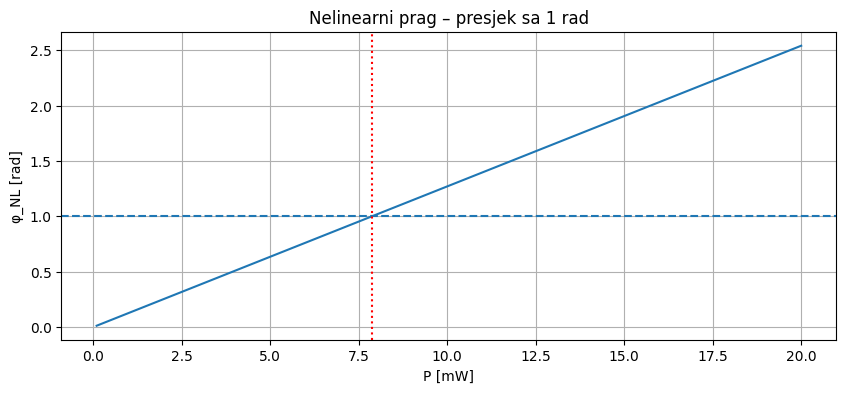

In [ ]:
# --- Vizualizacija nelinearnog praga (Poglavlje 6.6) ---

# Kreiranje finog niza snaga (od 0.1 do 20 mW) za glatko iscrtavanje funkcije
P_plot = np.linspace(0.1, 20, 400)

# Proračun nelinearne fazne rotacije (phi_nl) u zavisnosti od ulazne snage
# Formula: phi_nl = n_spans * gamma * P * L_eff (akumulacija kroz sve dionice)
phi_nl = n_spans * gamma * (P_plot*1e-3) * L_eff

plt.figure(figsize=(10,4))

# Iscrtavanje zavisnosti nelinearne faze o snazi
plt.plot(P_plot, phi_nl)

# Horizontalna linija na 1 radijan - definiše granicu nelinearnog praga (Slika 6.7)
plt.axhline(1, linestyle='--', label='1 radijan')

# Vertikalna linija na izračunatoj vrijednosti teorijskog praga
plt.axvline(P_th_mW, linestyle=':', color='red')

# Označavanje osa i naslov (prema terminologiji iz rada)
plt.xlabel('P [mW]')
plt.ylabel('φ_NL [rad]')
plt.title('Nelinearni prag – presjek sa 1 rad')

plt.grid()
plt.show()


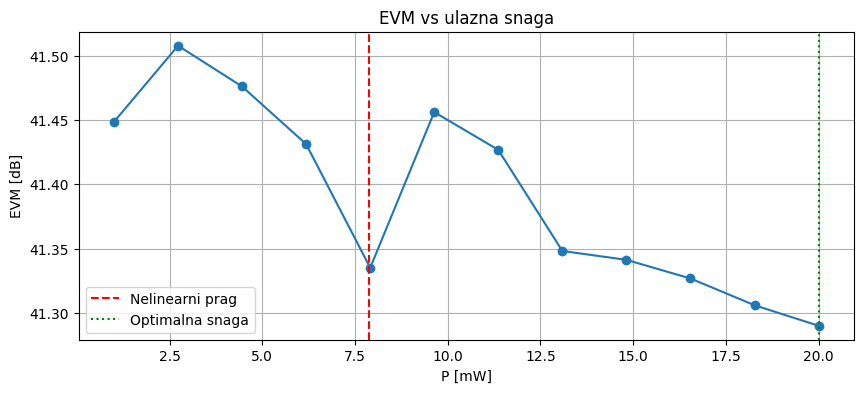

In [ ]:
# --- Vizualizacija EVM metrike (Poglavlje 6.1) ---

plt.figure(figsize=(10,4))

# Iscrtavanje simuliranih vrijednosti EVM-a (u dB) u zavisnosti od snage (u mW)
# 'marker=o' označava tačke u kojima je vršena simulacija (P_list)
plt.plot(P_arr, evm_arr, marker='o')

# Vertikalna linija za teorijski prag (phi_nl = 1 rad)
plt.axvline(P_th_mW, color='red', linestyle='--', label='Nelinearni prag')

# Vertikalna linija za optimalnu snagu (tačka gdje je EVM minimalan u simulaciji)
plt.axvline(P_opt_mW, color='green', linestyle=':', label='Optimalna snaga')

# Označavanje osa prema fizičkim veličinama iz rada
plt.xlabel('P [mW]')
plt.ylabel('EVM [dB]')
plt.title('EVM vs ulazna snaga')

plt.grid()
plt.legend()
plt.show()



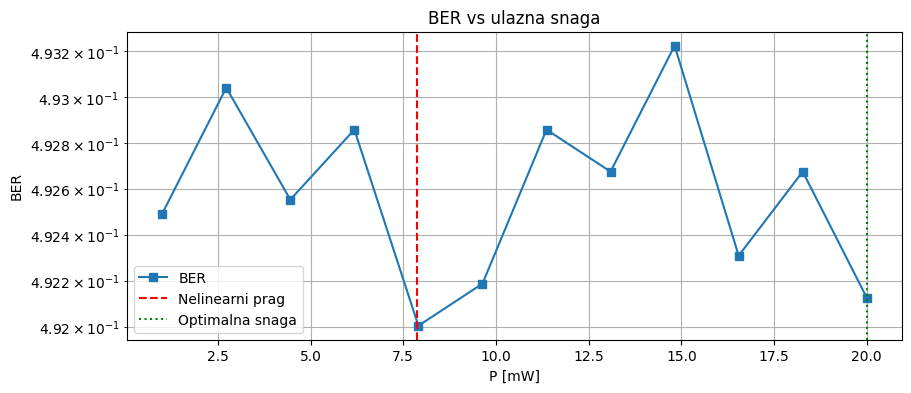

In [ ]:
# --- Vizualizacija BER metrike (Poglavlje 6.2) ---

plt.figure(figsize=(10,4))

# Koristi se semilogy (logaritamska skala za y-osu) jer BER obično varira kroz redove veličine
# 'marker=s' koristi kvadrate (squares) za označavanje simuliranih tačaka
plt.semilogy(P_arr, ber_list, marker='s', label='BER')

# Vertikalna linija za teorijski nelinearni prag (1 rad) izračunat u Poglavlju 6.6
plt.axvline(P_th_mW, color='r', linestyle='--', label='Nelinearni prag')

# Vertikalna linija za snagu pri kojoj je izmjerena najbolja performansa (min. EVM/BER)
plt.axvline(P_opt_mW, color='g', linestyle=':', label='Optimalna snaga')

# Označavanje osa i naslova
plt.xlabel('P [mW]')
plt.ylabel('BER')
plt.title('BER vs ulazna snaga')

# Uključivanje mreže za glavne i sporedne podjele (bitno za logaritamske grafike)
plt.grid(True, which='both')
plt.legend()
plt.show()


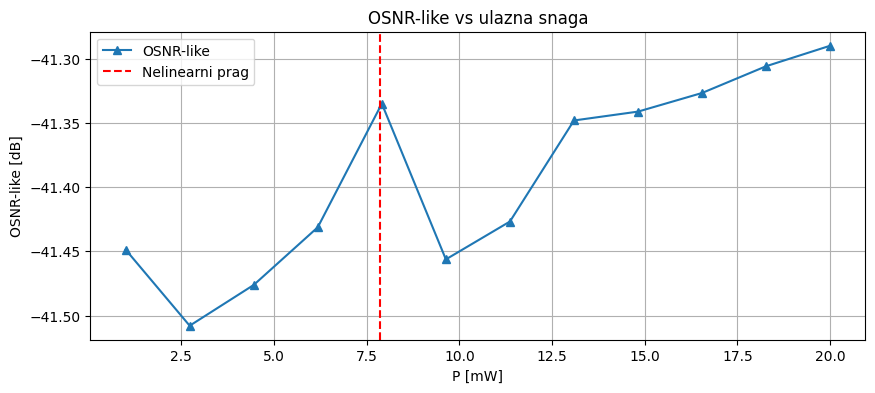

In [ ]:
# --- Vizualizacija OSNR-like metrike (Poglavlje 6.3) ---

plt.figure(figsize=(10,4))

# Iscrtavanje OSNR-like metrike (u dB) u zavisnosti od ulazne snage
# marker='^' (trougao) se koristi za označavanje simuliranih tačaka snage
plt.plot(P_arr, osnr_like, marker='^', label='OSNR-like')

# Prikaz teorijskog nelinearnog praga (crvena isprekidana linija)
plt.axvline(P_th_mW, color='r', linestyle='--', label='Nelinearni prag')

# Označavanje osa prema fizičkim veličinama i terminologiji iz rada
plt.xlabel('P [mW]')
plt.ylabel('OSNR-like [dB]')
plt.title('OSNR-like vs ulazna snaga')

plt.grid()
plt.legend()
plt.show()


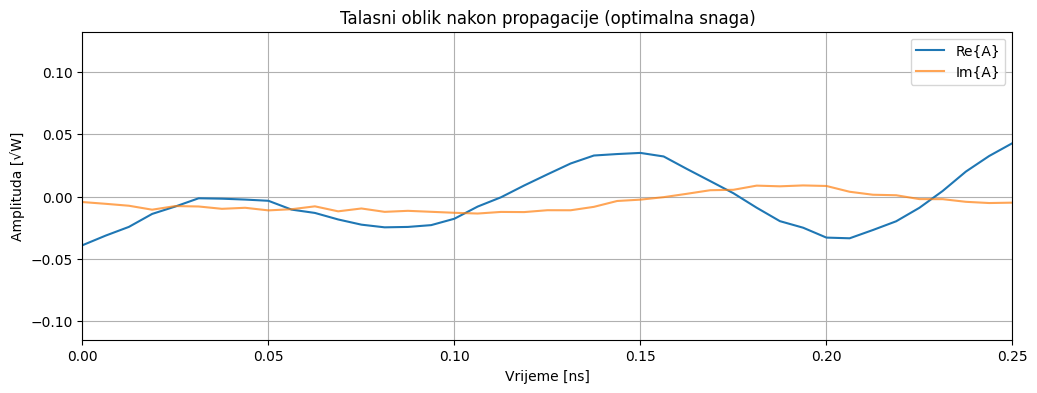

In [ ]:
# --- Priprema signala sa optimalnom snagom (Poglavlje 6.5) ---

# Pronalaženje vršne snage trenutnog bazičnog signala
peak = np.max(np.abs(x_tx)**2)

# Izračun faktora skaliranja za postizanje optimalne vršne snage (P_opt_mW)
scale_opt = np.sqrt((P_opt_mW*1e-3) / peak)
A_opt = x_tx * scale_opt

# --- Simulacija pune propagacije kroz sve dionice ---
for _ in range(n_spans):
    # Prolazak kroz vlakno pomoću SSFM metode (Poglavlje 4.2)
    for _ in range(N_steps_span):
        A_opt = ssfm_step(A_opt)
    # Pojačanje i dodavanje šuma u EDFA pojačalu (Poglavlje 4.3)
    A_opt = edfa(A_opt)

# --- Vizualizacija talasnog oblika (Slika 6.6) ---
plt.figure(figsize=(12,4))

# Iscrtavanje realnog dijela kompleksne omotačnice signala
plt.plot(t*1e9, np.real(A_opt), label='Re{A}')

# Iscrtavanje imaginarnog dijela signala (providnost 0.7 radi preglednosti)
plt.plot(t*1e9, np.imag(A_opt), label='Im{A}', alpha=0.7)

# Ograničavanje prikaza na prvih 5 simbola kako bi se vidjeli detalji talasnog oblika
plt.xlim(0, 5*(1/Rs)*1e9)

# Označavanje osa (Vrijeme u nanosekundama, Amplituda u korijenu vata)
plt.xlabel('Vrijeme [ns]')
plt.ylabel('Amplituda [√W]')
plt.title('Talasni oblik nakon propagacije (optimalna snaga)')

plt.grid()
plt.legend()
plt.show()


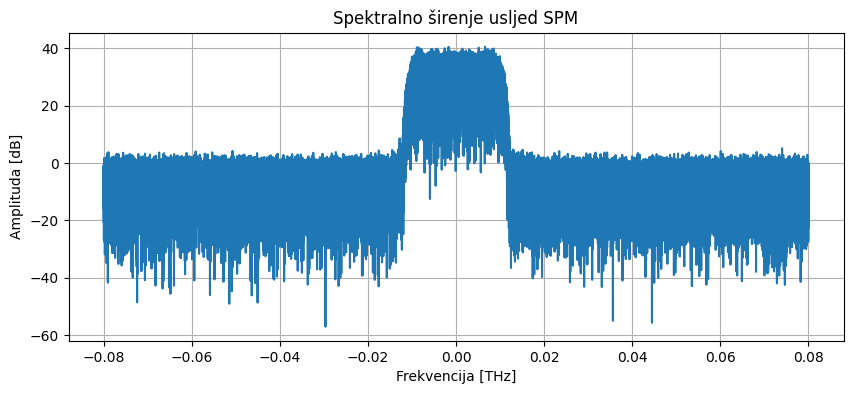

In [ ]:
# --- Spektralna analiza (Poglavlje 6.4) ---

# Prelazak iz vremenskog u frekvencijski domen pomoću brze Fourierove transformacije (FFT)
# np.fft.fftshift se koristi da bi se nulta frekvencija (centar spektra) pomjerila u sredinu grafika
S = np.fft.fftshift(np.fft.fft(A_opt))

# Pomjeranje vektora frekvencija (f) kako bi odgovarao centriranom spektru
f_shift = np.fft.fftshift(f)

plt.figure(figsize=(10,4))

# Iscrtavanje spektra u decibelima (dB) radi lakšeg uočavanja širenja na krilima spektra
# Frekvencija se skalira u teraherce (THz) množenjem sa 1e-12
# 1e-15 se dodaje unutar logaritma kako bi se izbjegla greška (log nula)
plt.plot(f_shift*1e-12, 20*np.log10(np.abs(S)+1e-15))

# Definisanje naziva osa i naslova prema terminologiji iz Poglavlja 6.4 (str. 21)
plt.xlabel('Frekvencija [THz]')
plt.ylabel('Amplituda [dB]')
plt.title('Spektralno širenje usljed SPM')

plt.grid()
plt.show()


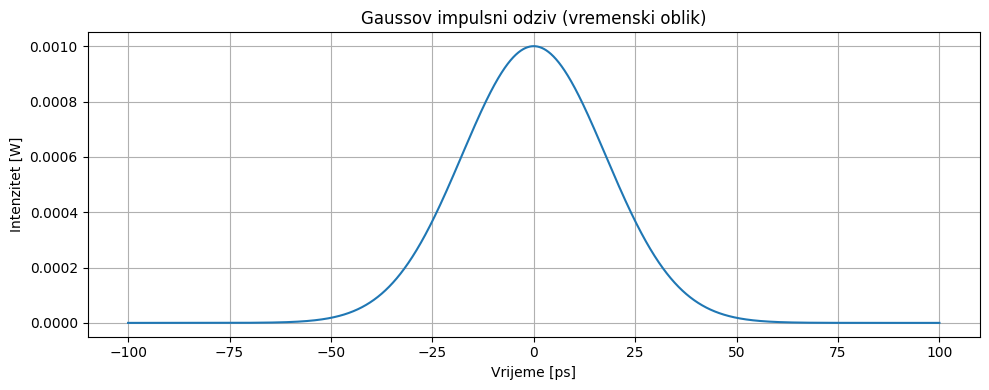

In [ ]:
# ===============================================================
# Generisanje Gaussovog impulsa (Poglavlje 6.4, str. 16 i 17)
# ===============================================================

# Osnovni parametri impulsa
T_pulse = 50e-12                 # Trajanje impulsa postavljeno na 50 ps
Nt = 2**12                       # Broj uzoraka (4096 tačaka) za visoku rezoluciju
# Vremenska os centrirana oko nule za simetričan prikaz impulsa
t = np.linspace(-2*T_pulse, 2*T_pulse, Nt)

# Karakteristike snage i oblika
P0 = 1e-3                        # Vršna snaga postavljena na 1 mW
sigma = T_pulse / 2              # Standardna devijacija (širina) Gaussovog oblika

# Definisanje kompleksne amplitude Gaussovog impulsa (Jednačina 3.3 bez disperzije)
# Impuls je inicijalno bez faznog pomaka (+ 0j)
A = np.sqrt(P0) * np.exp(-t**2 / (2*sigma**2)) + 0j

# ===============================================================
# Prikaz inicijalnog impulsa (Slika 6.4 - gornji dijagram)
# ===============================================================

plt.figure(figsize=(10,4))

# Iscrtavanje intenziteta impulsa (kvadrat apsolutne vrijednosti amplitude)
# Vrijeme se skalira u pikosekunde (ps) množenjem sa 1e12
plt.plot(t*1e12, np.abs(A)**2)

# Označavanje osa prema fizičkim veličinama iz rada
plt.xlabel("Vrijeme [ps]")
plt.ylabel("Intenzitet [W]")
plt.title("Gaussov impulsni odziv (vremenski oblik)")

plt.grid()
plt.tight_layout()
plt.show()


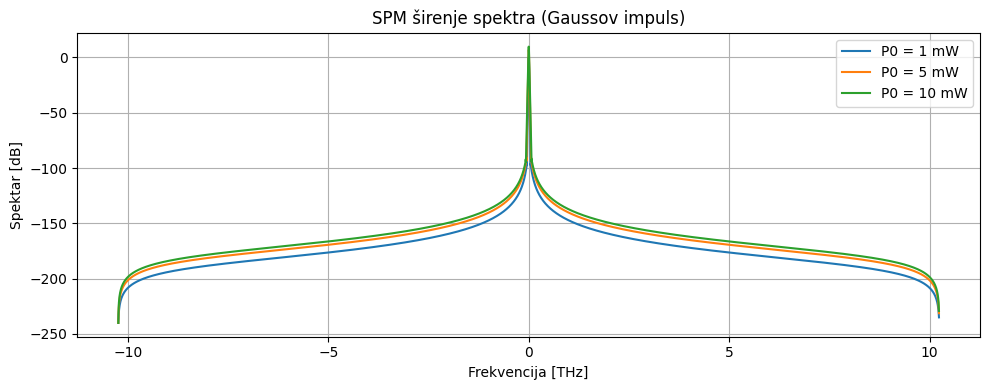

In [ ]:
# ===============================================================
# Gaussov impuls - Inicijalizacija (Poglavlje 6.4)
# ===============================================================
T_pulse = 50e-12                 # Trajanje impulsa (50 ps)
Nt = 2**12                       # Broj tačaka uzorkovanja
t = np.linspace(-2*T_pulse, 2*T_pulse, Nt)
dt = t[1] - t[0]                 # Vremenski korak između uzoraka
sigma = T_pulse / 2              # Širina impulsa

# ===============================================================
# Parametri vlakna - Fokus na čistoj nelinearnosti (Poglavlje 3.2)
# ===============================================================
# U ovoj demonstraciji koristimo samo nelinearni koeficijent (beta2=0, alpha=0)
gamma = 1.3e-3                   # Nelinearni koeficijent [1/W/m]
L = 50e3                         # Dužina propagacije (50 km)
dz = 100                         # Prostorni korak [m]
steps = int(L / dz)              # Broj iteracija za nelinearni pomak

# ===============================================================
# Frekvencijska osa - Priprema za prikaz spektra
# ===============================================================
# Centriranje frekvencijske ose oko nule (baseband prikaz)
f = np.fft.fftshift(np.fft.fftfreq(Nt, dt))

# ===============================================================
# Simulacija za tri nivoa snage (1, 5 i 10 mW)
# ===============================================================
P0_list = [1e-3, 5e-3, 10e-3]
spectra = []

# Proračun propagacije za svaku ulaznu snagu posebno
for P0 in P0_list:
    # Definisanje početne amplitude Gaussovog impulsa
    A = np.sqrt(P0) * np.exp(-t**2/(2*sigma**2)) + 0j

    # Primjena samo nelinearnog operatora (Jednačina 4.3 iz rada)
    # Budući da nema disperzije, vremenski oblik impulsa ostaje nepromijenjen
    for _ in range(steps):
        # Akumulacija nelinearne faze (SPM efekt)
        A *= np.exp(1j * gamma * np.abs(A)**2 * dz)

    # Prelazak u frekvencijski domen nakon propagacije
    S = np.fft.fftshift(np.fft.fft(A))
    spectra.append(np.abs(S))

# ===============================================================
# Normalizacija i vizualizacija (Slika 6.4 - donji dijagram)
# ===============================================================
# Normalizacija u odnosu na najslabiji impuls (1 mW) radi lakšeg poređenja
S_ref = np.max(spectra[0])

plt.figure(figsize=(10,4))
for S, P0 in zip(spectra, P0_list):
    # Pretvaranje u decibele (dB) uz zaštitu od log(0)
    S_dB = 20*np.log10(S / S_ref + 1e-12)
    # Frekvencija skalirana u Teraherce [THz]
    plt.plot(f*1e-12, S_dB, label=f"P0 = {P0*1e3:.0f} mW")

# Definisanje grafičkog prikaza prema Poglavlju 6.4 tvog rada
plt.xlabel("Frekvencija [THz]")
plt.ylabel("Spektar [dB]")
plt.title("SPM širenje spektra (Gaussov impuls)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
